In [4]:
# 누락데이터 확인

import seaborn as sns

df= sns.load_dataset('titanic')

df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
df['deck'].value_counts(dropna=False)

deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64

In [6]:
df.head().isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [7]:
df.head().notnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True


In [8]:
df.head().isnull().sum(axis=0)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           3
embark_town    0
alive          0
alone          0
dtype: int64

In [9]:
df['deck'].isnull().sum()

np.int64(688)

<Axes: >

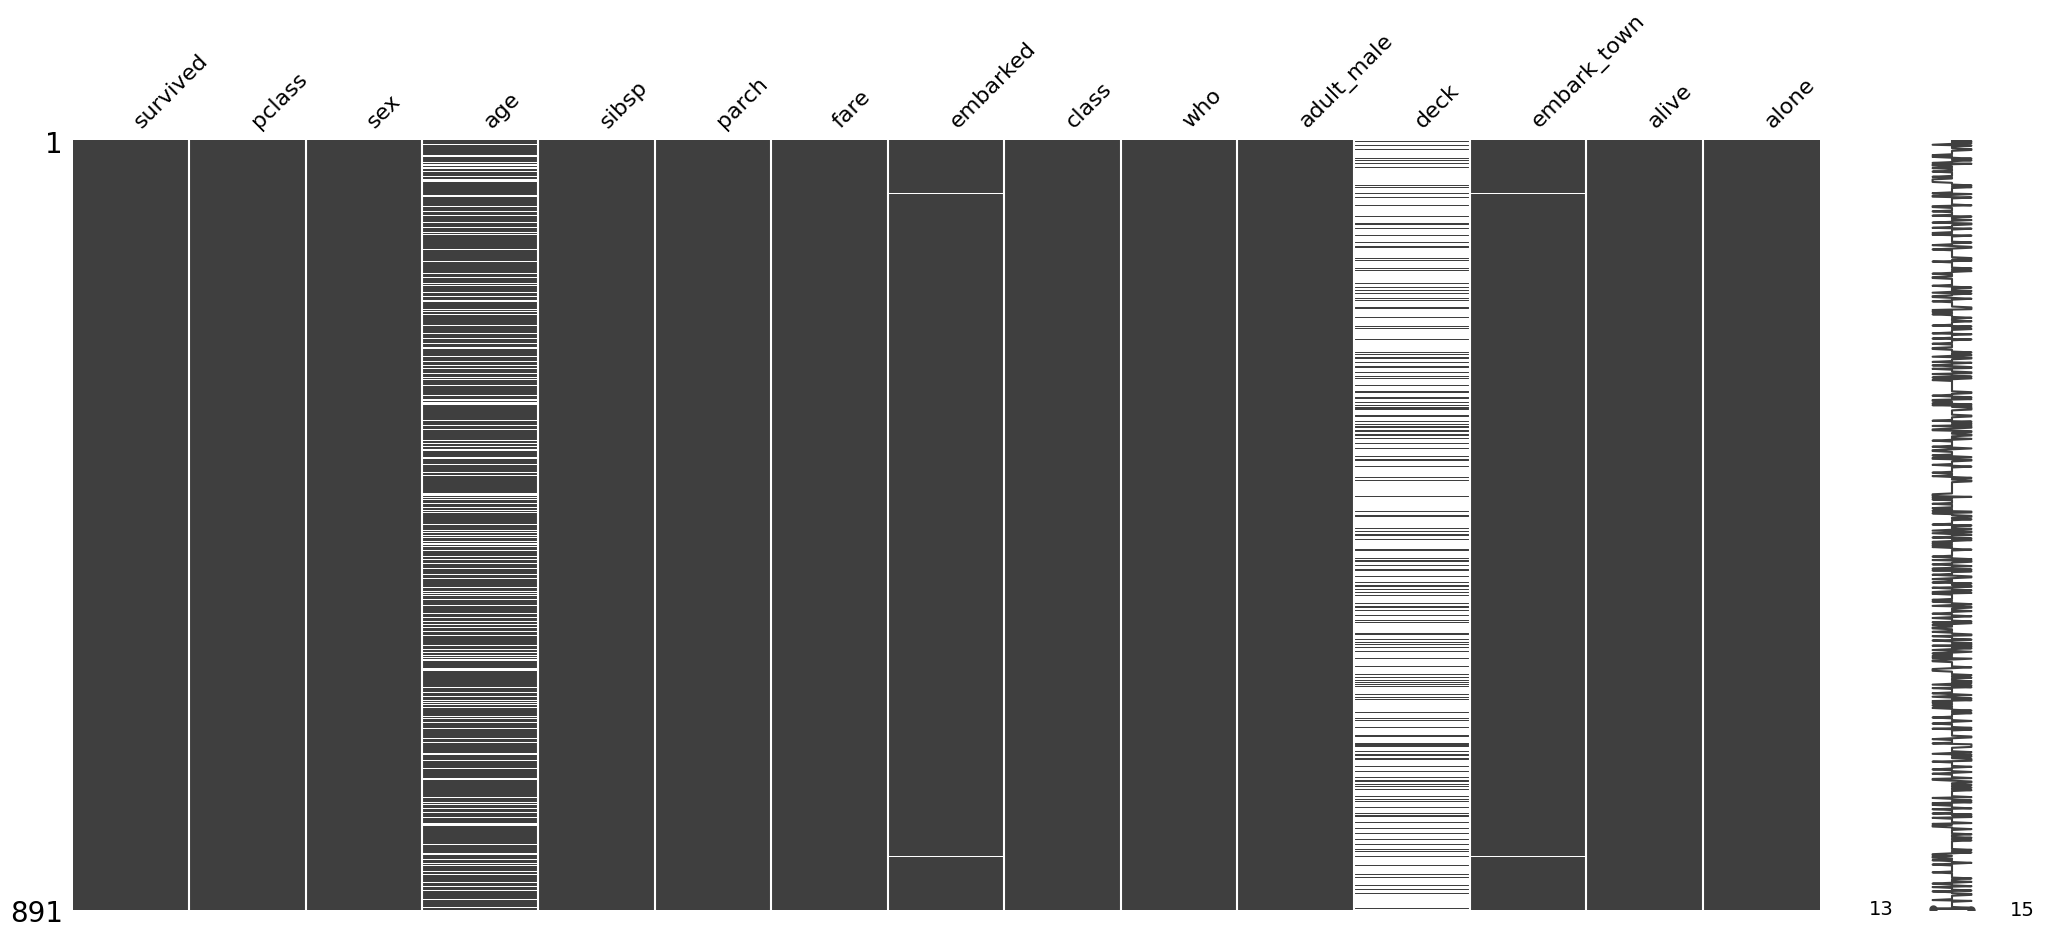

In [10]:
# 구락 데이터 확인 missingno라이브러리 설치

import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)

In [2]:
# 누락데이터 제거

import seaborn as sns

df = sns.load_dataset('titanic')

df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# 모든 결측치 제거

df_null = df.dropna().isnull().sum()
df_null.isnull().sum()

np.int64(0)

In [7]:
# thresh 임계값

print(df_null)
print('\n'*2)
df_thresh = df.dropna(axis=1, thresh=500)
print(df_thresh.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64



survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:

print(len(df['age']))
print('\n')
df_age = df.dropna(subset=['age'], how='any', axis=0)
print(len(df_age['age']))

891


714


In [13]:
print(df.loc[:, ['age', 'deck']].isnull().sum())
df_age_deck = df.dropna(subset=['age', 'deck'], how='all', axis=0)
print()
print()
print(df_age_deck.loc[:, ['age', 'deck']].isnull().sum())

age     177
deck    688
dtype: int64


age      19
deck    530
dtype: int64


In [17]:
import numpy as np
import pandas as pd

data = {
    "대구" : [10, np.nan, np.nan],
    "부산" : [1, np.nan, 5],
    "서울" : [np.nan, np.nan, 10]
}

test1 = pd.DataFrame(data)
test1

,대구,부산,서울
0,10.0,1.0,NaN
1,NaN,NaN,NaN
2,NaN,5.0,10.0


In [19]:
test_re = test1.dropna(subset=["대구"])
test_re

,대구,부산,서울
0,10.0,1.0,NaN


In [20]:
test2 = test1.dropna(subset=["대구", "부산"], how = 'all')
test2

,대구,부산,서울
0,10.0,1.0,NaN
2,NaN,5.0,10.0


In [25]:
# 누락데이터 대체

df['age'].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

In [28]:
mean_age = df['age'].mean()
mean_age

np.float64(29.69911764705882)

In [34]:
print(df['age'].isnull().sum())
df['age'] = df['age'].fillna(mean_age)
print()
print(df['age'].isnull().sum())

0

0


In [35]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [47]:
town = df['embark_town'][825:830]
town

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
Name: embark_town, dtype: str

In [44]:
most_freq = town.value_counts().idxmax()
print(most_freq)

Queenstown


In [43]:
most_freq2 = town.mode()[0]
print(most_freq2)

Queenstown


In [48]:
print(town)
town = town.fillna(most_freq)
print()
print(town)


825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
Name: embark_town, dtype: str

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829     Queenstown
Name: embark_town, dtype: str


In [53]:
df2 = df.copy()
df['embark_town'][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
830      Cherbourg
Name: embark_town, dtype: str

In [55]:
df['embark_town'] = df['embark_town'].ffill()
df['embark_town'][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829     Queenstown
830      Cherbourg
Name: embark_town, dtype: str

In [57]:
df2['embark_town'][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
830      Cherbourg
Name: embark_town, dtype: str

In [58]:
df2['embark_town'] = df2['embark_town'].bfill()
df2['embark_town'][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829      Cherbourg
830      Cherbourg
Name: embark_town, dtype: str